In [66]:
#Final Project
#ISTA 421
#Paul Allen

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [68]:
# Loading in the same earthquake data as last time
dataset = pd.read_csv("earthquake_data.csv")

print("Raw shape:", dataset.shape)
print("Columns:", list(dataset.columns))

Raw shape: (4756, 22)
Columns: ['ObjectID', 'GlobalID', 'Date', 'Seconds', 'Depth', 'Magnitude', 'Mercalli', 'Type', 'Number of Phases', 'Rms', 'Erh', 'Erz', 'Source Catalog', 'Location', 'Notes', 'CreationDate', 'Creator', 'EditDate', 'Editor', 'TImeTest', 'x', 'y']


In [69]:
#Cleaning the data, pretty much copying what I did in HW3

# Removing un-relevant columns
cols_drop = ['GlobalID', 'TImeTest', 'Mercalli', 'CreationDate', 'EditDate', 'Location', 'Notes']
dataset_clean = dataset.drop(columns=cols_drop)

#convert black columns into NaN, in case they are not, to make filtering easier
cols_check = ['Seconds', 'Depth', 'Magnitude', 'Number of Phases', 'Rms', 'Erh', 'Erz', 'x', 'y']
dataset_clean[cols_check] = dataset_clean[cols_check].apply(pd.to_numeric, errors="coerce")

# Remove rows where NaN or zero
not_null = dataset_clean[cols_check].notna().all(axis=1)
not_zero = (dataset_clean[cols_check] != 0).all(axis=1)

mask = not_null & not_zero
dataset_clean = dataset_clean[mask].reset_index(drop=True)

print("Cleaned shape:", dataset_clean.shape)

Cleaned shape: (789, 15)


In [70]:
#Some extra cleaning

# Weirdly high rms value removed
dataset_clean = dataset_clean[dataset_clean["Rms"] <= 20].copy()
print("After Rms filter:", dataset_clean.shape)

# Couple of clear data entry errors
dataset_clean = dataset_clean[dataset_clean["x"].between(-115, -109)] #Keep within bounds of Arizona, some weird lat/lon
dataset_clean = dataset_clean[dataset_clean["y"].between(31, 38)]
dataset_clean = dataset_clean.dropna(subset=["Type"]).reset_index(drop=True)
print("After error filter:", dataset_clean.shape)

# Drop the Mw events (since there is only 3)
dataset_clean = dataset_clean[dataset_clean["Type"] != "Mw"].copy()

# Type is now binary 1 if ML, 0 if MD
dataset_clean["Type_ML"] = (dataset_clean["Type"] == "ML").astype(int)


After Rms filter: (788, 15)
After error filter: (785, 15)


In [71]:
#Target and Predictors

# Features & target
target = "Magnitude"
features = ["Depth", "Number of Phases", "Rms", "Erh", "Erz", "x", "y", "Type_ML"]

X = dataset_clean[features].to_numpy()
y = dataset_clean[target].to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (782, 8)
y shape: (782,)


In [72]:
# Summary stats for all features + target
print(dataset_clean[features + [target]].describe().round(2)) #cool little function

        Depth  Number of Phases     Rms     Erh     Erz       x       y  \
count  782.00            782.00  782.00  782.00  782.00  782.00  782.00   
mean    12.98             12.79    0.43    2.43    5.10 -112.34   35.79   
std      9.10              8.23    0.34    2.61    5.94    1.12    1.23   
min     -3.50              4.00    0.01    0.10    0.17 -114.75   31.26   
25%      5.00              8.00    0.18    0.80    1.36 -113.00   35.16   
50%     12.40             10.00    0.31    1.48    2.62 -112.48   36.08   
75%     19.30             15.00    0.62    2.92    6.92 -111.81   36.85   
max     58.50             74.00    2.46   19.39   69.31 -109.02   37.18   

       Type_ML  Magnitude  
count   782.00     782.00  
mean      0.94       1.74  
std       0.24       0.59  
min       0.00       0.40  
25%       1.00       1.30  
50%       1.00       1.60  
75%       1.00       2.00  
max       1.00       4.50  


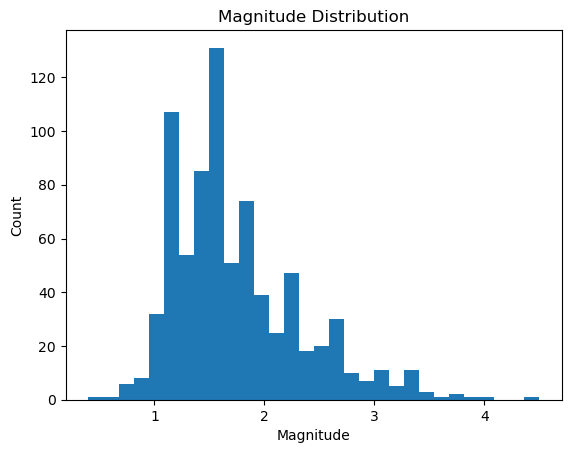

Mean: 1.74
Median: 1.6


In [73]:
# Magnitude distribution
plt.figure()
plt.hist(dataset_clean["Magnitude"], bins=30)
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.title("Magnitude Distribution")
plt.show()

print("Mean:", round(dataset_clean["Magnitude"].mean(), 2))
print("Median:", round(dataset_clean["Magnitude"].median(), 2))

Type
ML    732
MD     50
Name: count, dtype: int64

      count  mean   std  min  max
Type                             
MD       50  1.60  0.34  1.0  2.3
ML      732  1.75  0.60  0.4  4.5


<Figure size 640x480 with 0 Axes>

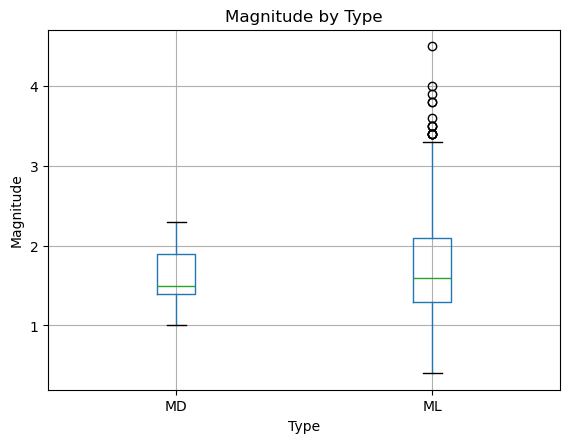

In [74]:
# Type breakdown
print(dataset_clean["Type"].value_counts())
print()
print(dataset_clean.groupby("Type")["Magnitude"].agg(['count','mean','std','min','max']).round(2))

# Boxplot to see if the two scales actually differ
plt.figure()
dataset_clean.boxplot(column="Magnitude", by="Type")
plt.suptitle("")
plt.title("Magnitude by Type")
plt.ylabel("Magnitude")
plt.show()

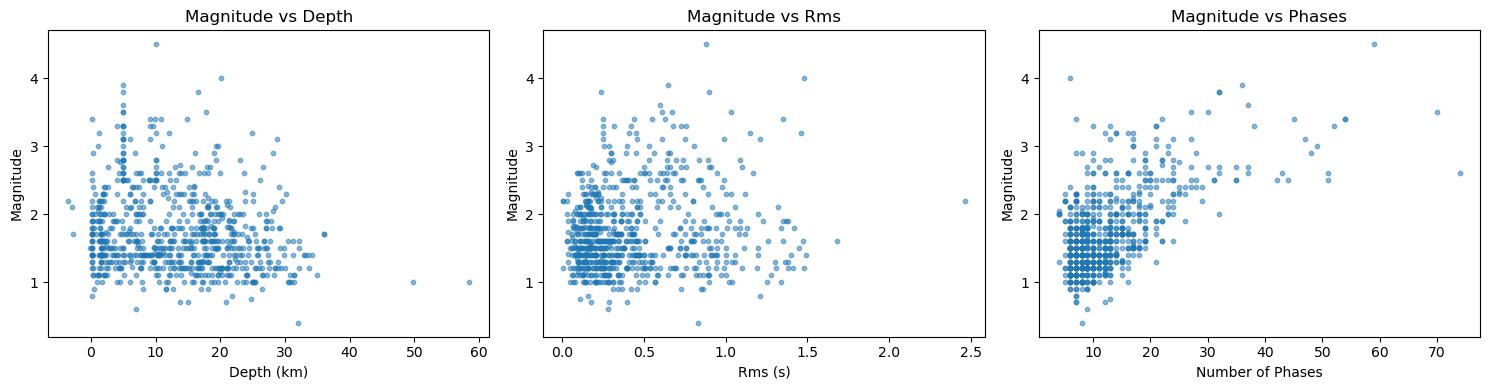

In [75]:
# Three Scatter Plots (from HW3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#depth v mag
axes[0].scatter(dataset_clean["Depth"], dataset_clean["Magnitude"], s=10, alpha=0.5)
axes[0].set_xlabel("Depth (km)")
axes[0].set_ylabel("Magnitude")
axes[0].set_title("Magnitude vs Depth")

#rms v mag
axes[1].scatter(dataset_clean["Rms"], dataset_clean["Magnitude"], s=10, alpha=0.5)
axes[1].set_xlabel("Rms (s)")
axes[1].set_ylabel("Magnitude")
axes[1].set_title("Magnitude vs Rms")

#phases v mag
axes[2].scatter(dataset_clean["Number of Phases"], dataset_clean["Magnitude"], s=10, alpha=0.5)
axes[2].set_xlabel("Number of Phases")
axes[2].set_ylabel("Magnitude")
axes[2].set_title("Magnitude vs Phases")

plt.tight_layout()
plt.show()

In [76]:
# Correlations of features with target and each other
corr = dataset_clean[features + [target]].corr()
print(corr.round(2))

# Just the magnitude column, sorted
print("\nSorted by correlation with Magnitude:")
print(corr["Magnitude"].sort_values(ascending=False).round(2))

                  Depth  Number of Phases   Rms   Erh   Erz     x     y  \
Depth              1.00             -0.16 -0.06  0.10 -0.30 -0.08  0.13   
Number of Phases  -0.16              1.00  0.05 -0.22 -0.10 -0.12  0.07   
Rms               -0.06              0.05  1.00  0.71  0.26  0.22 -0.35   
Erh                0.10             -0.22  0.71  1.00  0.28  0.18 -0.26   
Erz               -0.30             -0.10  0.26  0.28  1.00  0.02 -0.07   
x                 -0.08             -0.12  0.22  0.18  0.02  1.00 -0.65   
y                  0.13              0.07 -0.35 -0.26 -0.07 -0.65  1.00   
Type_ML            0.02              0.10  0.24  0.13  0.03  0.08 -0.14   
Magnitude         -0.19              0.61  0.13 -0.07 -0.05  0.14 -0.22   

                  Type_ML  Magnitude  
Depth                0.02      -0.19  
Number of Phases     0.10       0.61  
Rms                  0.24       0.13  
Erh                  0.13      -0.07  
Erz                  0.03      -0.05  
x              

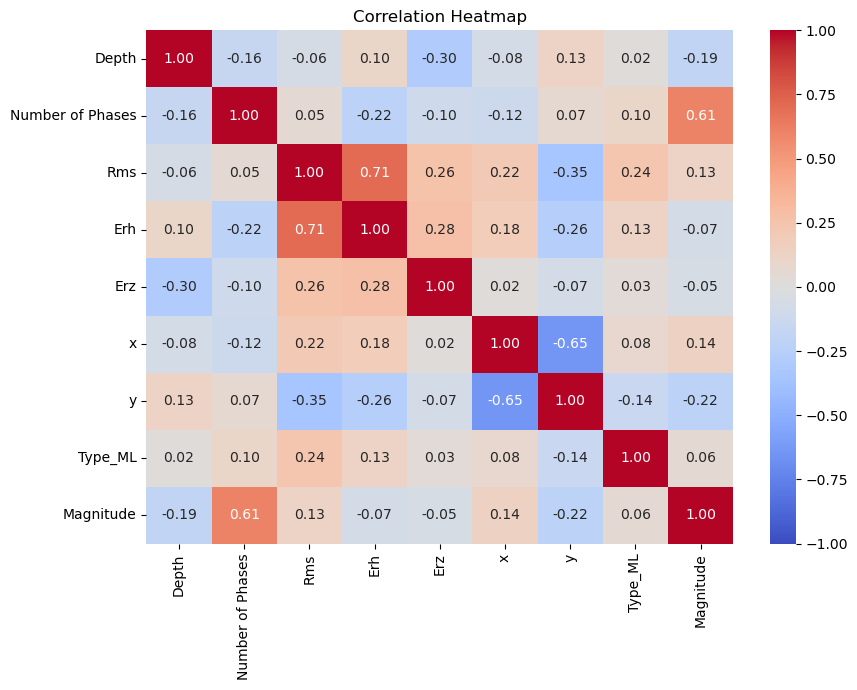

In [77]:
# Heatmap 
#I love these things, they are like abstract art
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()